In [1]:
#%matplotlib notebook
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import json
from pathlib import Path
from random import shuffle

In [3]:
import acanalysis.acalignment.match_keypoints as mk
from acanalysis.acalignment.keypoints import write_keypoints_to_file,read_keypoints,transform_keypoints
from acanalysis.acalignment.transforms import ransac
from acanalysis.acalignment.utils.kevin_utils import get_section_label, get_roi_label

In [4]:
# Alignment json describing the set of segmented ROI's (SROI's) from each
# section image to be jointly aligned, the image (zarr) data cutout regions
# underlying the segmentation, and file path information to locate
# the zarr datasets and skeletons
align_json = "align_S32_S33_roi2_mip1_240403.json"
with open(align_json) as f:
    alignjs = json.load(f)
outpath = Path(alignjs["output_path"])
#global_reg_matrix_path = Path("J:/Users/kevin/alignment_files/M0_roi2.npy")
#global_reg_matrix_path = Path("J:/Users/kevin/alignment_files/for_wanqing/model.npy")
global_reg_matrix_path = Path("./roi4_mip1_240408/model.npy")

In [5]:
# coarse initialization from global registration
M0 = np.load(global_reg_matrix_path)
print(M0)

[[ 9.68183488e-01  2.50241349e-01 -7.33786454e+03]
 [-2.50241349e-01  9.68183488e-01 -6.12946036e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [6]:
# combine keypoints from SROI's in each section
combined_kps = []
for s in alignjs["sections"]:
    tiles = s["tiles"]
    offsets = s["position_offsets"]
    rois = [outpath / Path(get_roi_label(s,i) + "_keypoints.json") for i,tid in enumerate(tiles)]
    kps = mk.combine_tile_keypoints(rois,offsets,shuffle=False)
    print(len(kps))
    combined_kps.append(kps)

1157
1054


In [7]:
# function to filter out keypoints with vectors parallel to horizontal (surface)
def filter_angles(keypts,maxangle):
    vecs = [kp.vector for kp in keypts]
    angles = np.arccos(np.array([np.abs(np.dot(np.array([1,0,0]),v)) for v in vecs]))*180/np.pi
    return [keypts[i] for i in np.nonzero(angles<maxangle)[0]]

def filter_sub_roi(keypts,coords,tform=None,axes=None):
    coord_axes = [a for a in range(len(coords)) if coords[a]]
    if tform is None:
        locs = np.array([k.location for k in keypts])
    else:
        locs,vecs = transform_keypoints(keypts,tform,axes)
    return [kp for i,kp in enumerate(keypts) if all([(locs[i,a]>=coords[a][0])and(locs[i,a]<coords[a][1]) for a in coord_axes])]

def apply_transform(keypts,rigidM,axes=None):
    locs,vecs = transform_keypoints(keypts,rigidM,axes)
    for kp,loc,vec in zip(keypts,locs,vecs):
        kp.location = loc
        kp.vector = vec
        
def combine_matrices(M_list):
    M_out = np.eye(3)
    for M in M_list:
        M_out = M @ M_out
    return M_out

In [8]:
# filter keypoints by angle of impact
filter_params = [
    {
    "angle":75,
    "coords":None,#[[],[1000,3000],[0,6000]], #None
    "tform":None
    },
    {
    "angle":75,
    "coords":None,#[[],[1000,3000],[0,6000]], #None
    "tform":M0
    }
]
filtered_kps = []
for kps,params in zip(combined_kps,filter_params):
    kps1 = kps
    if not params["angle"] is None:
        kps1 = filter_angles(kps1,params["angle"])
    if not params["coords"] is None:
        kps1 = filter_sub_roi(kps1,params["coords"],params["tform"],[1,2])
    filtered_kps.append(kps1)
    print(len(kps1))

820
751


In [9]:
offset_M = [np.eye(3),np.eye(3)]
offset_M[0][1,2] = 0
offset_M[1][1,2] = 0
#offset_M[0][1,2] = -23000
#offset_M[1][1,2] = -25600


offset_kps = [[kp.copy() for kp in keypts] for keypts in filtered_kps]
for keypts,M in zip(offset_kps,offset_M):
    apply_transform(keypts,M,[1,2])

In [10]:
import concurrent
# parameter search with loose solve to refine initial estimate
# by number of consensus inliers over rotation angle and translation
def match_ransac_for_theta(kps0,kps1,theta,trans,tforms0=None,tforms1=None):
    minmatches = 5
    if tforms1 is None:
        tforms1 = [np.eye(3)]
    R = np.array([[np.cos(theta), np.sin(theta), 0],
                  [-np.sin(theta), np.cos(theta), 0],
                  [0,0,1]])
    T = np.array([[1, 0, trans[0]],
                  [0, 1, trans[1]],
                  [0,0,1]])
    M = np.linalg.inv(T) @ R @ T
    tforms1.insert(0,M)
    match0,match1,distances = mk.match_keypoint_sets(kps0,kps1,axes=[1,2],tforms0=tforms0,tforms1=tforms1,rball=100,mincosine=0.6)
    tforms1.pop(0)
    if len(match0) >= minmatches:
        dst_pts = np.array([kp.location[1:] for kp in match0])
        src_pts = np.array([kp.location[1:] for kp in match1])
        best_model,best_inliers = ransac([src_pts,dst_pts],epsilon=50,iterations=1000,minNumInliers=6,showProgress=False)
        return best_model,best_inliers
    else:
        return None,None
    
def search_grid_at_theta(kp0,kp1,theta,trans0,dx,tforms0=None,tforms1=None):
    most_inliers = 0
    best_inliers = None
    best_model = None
    grid_out = np.zeros((len(dx),len(dx)))
    for i0,x0 in enumerate(dx):
        for i1,x1 in enumerate(dx):
            T = np.array([[1, 0, x0],
                  [0, 1, x1],
                  [0,0,1]])
            if tforms1 is None:
                tforms1 = [T]
            else:
                tforms1.append(T)
            model,inliers = match_ransac_for_theta(kp0,kp1,theta,trans0,tforms0=tforms0,tforms1=tforms1)
            if not inliers is None:
                grid_out[i0,i1] = np.sum(inliers)
                if np.sum(inliers) > most_inliers:
                    best_inliers = inliers
                    most_inliers = np.sum(inliers)
                    best_model = model
            tforms1.pop()
    print("calculated for " + str(theta))
    return theta,best_model,best_inliers,grid_out

def parallel_search(keypts0,keypts1,thetas,trans0,dx,M0,concurrency=5):
    with concurrent.futures.ProcessPoolExecutor(max_workers=concurrency) as e:
        futs = []
        for theta in thetas:
            futs.append(e.submit(search_grid_at_theta,kp0=keypts0,kp1=keypts1,theta=theta,trans0=trans0,dx=dx,M0=M0))
        results = [fut.result() for fut in concurrent.futures.as_completed(futs)]
    return results

In [11]:
# set up and run parameter search
theta0 = 0*np.pi/180
trans0 = np.array([-780,-2000])#np.array([-2750,-5000])#
dt = np.arange(-30,30.5,1)*np.pi/180
#dt = np.array([0])
#dx = np.arange(-500,501,50)
dx = np.array([0])
kp0 = filtered_kps[0]
kp1 = filtered_kps[1]
tf0 = [offset_M[0]]
tf1 = [offset_M[1],M0]
results = [search_grid_at_theta(kp0,kp1,theta0+t,trans0,dx,tforms0=tf0,tforms1=tf1) for t in dt]

calculated for -0.5235987755982988
calculated for -0.5061454830783556
calculated for -0.4886921905584123
calculated for -0.47123889803846897
calculated for -0.4537856055185257
calculated for -0.4363323129985824
calculated for -0.41887902047863906
calculated for -0.40142572795869574
calculated for -0.3839724354387525
calculated for -0.3665191429188092
calculated for -0.3490658503988659
calculated for -0.3316125578789226
calculated for -0.3141592653589793
calculated for -0.29670597283903605
calculated for -0.2792526803190927
calculated for -0.2617993877991494
calculated for -0.24434609527920614
calculated for -0.22689280275926285
calculated for -0.20943951023931953
calculated for -0.19198621771937624
calculated for -0.17453292519943295
calculated for -0.15707963267948966
calculated for -0.13962634015954636
calculated for -0.12217304763960307
calculated for -0.10471975511965977
calculated for -0.08726646259971647
calculated for -0.06981317007977318
calculated for -0.05235987755982988
calc

In [12]:
res_arr = np.array([[r[0],np.sum(r[2])] for r in results])
models = [r[1] for r in results]

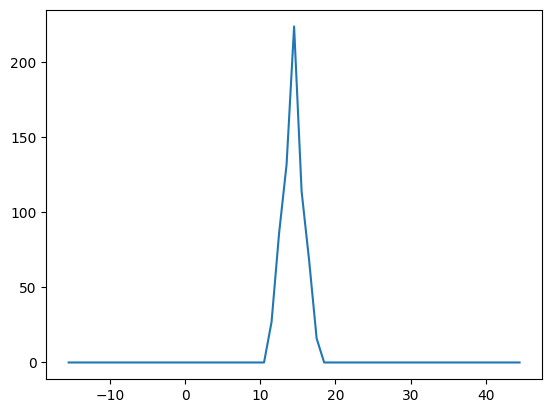

In [13]:
n = res_arr[:,1]
n[n==np.array(None)] = 0
plt.plot((res_arr[:,0]+np.arcsin(M0[0,1]))*180/np.pi,n)

In [14]:
imax = np.argmax(n)
print(imax)
print(res_arr[:,0][imax]*180/np.pi)
M1 = models[imax].M
print(M1)

28
-2.0
[[ 9.75160593e-01  2.21499025e-01 -7.48701888e+03]
 [-2.21499025e-01  9.75160593e-01 -6.23006814e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [15]:
# set up and run parameter search
theta0 = 0*np.pi/180
#trans0 = np.array([-2750,-5000])
#dt = np.arange(-20,20.5,1)*np.pi/180
dt = np.array([0])
dx = np.arange(-500,501,50)
kp0 = filtered_kps[0]
kp1 = filtered_kps[1]
results2 = [search_grid_at_theta(kp0,kp1,theta0+t,trans0,dx,tforms0=None,tforms1=[M1]) for t in dt]

calculated for 0.0


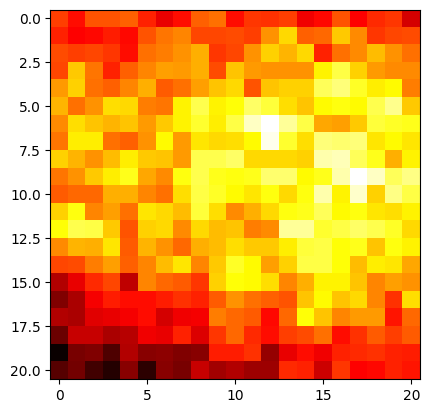

In [16]:
plt.imshow(results2[0][3], cmap='hot', interpolation='nearest')
plt.show()

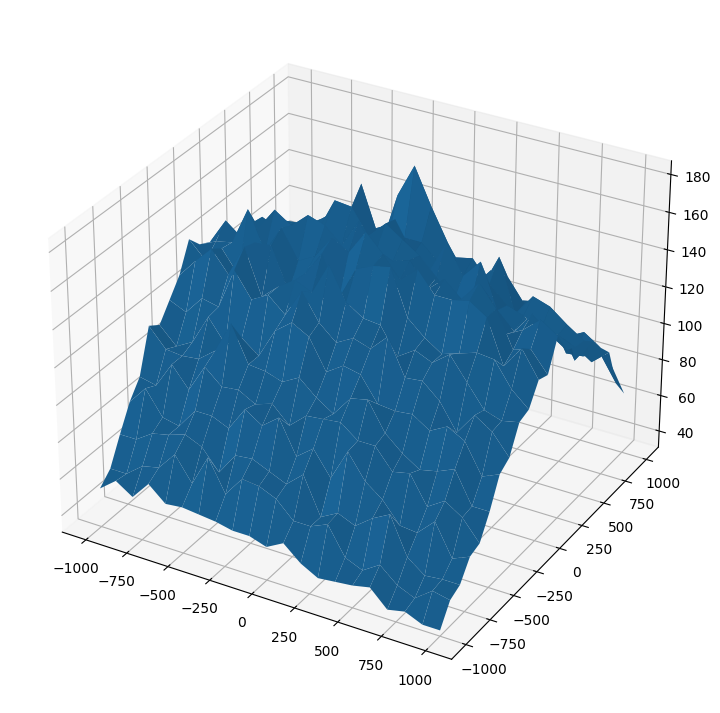

In [17]:
_xx, _yy = np.meshgrid(dx,dx)
_zz = results2[0][3]
# Creating figure
fig = plt.figure(figsize =(14, 9))
ax = plt.axes(projection ='3d')
 
# Creating plot
ax.plot_surface(_xx, _yy, _zz)
 
# show plot
plt.show()

In [17]:
# refined initial estimate of rigid transformation matrix to align sections
#rigid_M = M1
rigid_M = results2[0][1].M
#rigid_M = models[imax].M
print(offset_M[0] @ rigid_M @ np.linalg.inv(offset_M[1]))
print(M0)

[[ 9.78142255e-01  2.07936837e-01 -7.22136557e+03]
 [-2.07936837e-01  9.78142255e-01 -6.31825162e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[[ 9.68183488e-01  2.50241349e-01 -7.33786454e+03]
 [-2.50241349e-01  9.68183488e-01 -6.12946036e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [18]:
print(np.arcsin(rigid_M[0,1])*180/np.pi)

12.001472945697492


In [19]:
# tight matching for correspondence generation
# match keypoints between sections based on lying within "aligned" neighborhood (ball query)
# and highest alignment of vectors (cosine)
match0,match1,distances = mk.match_keypoint_sets(kp0,kp1,axes=[1,2],tforms0=None,tforms1=[rigid_M],rball=100,mincosine=0.6)
print(len(match0))

629


In [20]:
# ignore z (height) coordinate for 2D alignment of locations
# projects endpoints onto a flat plane
pts0_dst = np.array([kp.location[1:] for kp in match0])
pts1_src = np.array([kp.location[1:] for kp in match1])

In [25]:
# ransac for rigid transformation and correspondences
best_model,best_inliers = ransac([pts1_src,pts0_dst],epsilon=50,iterations=10000,minNumInliers=6,showProgress=True)

0 : 157
1 : 177
8 : 181
16 : 182
19 : 187
26 : 190
92 : 192
108 : 194
1272 : 196
4483 : 197
4500 : 197


In [26]:
# rigid transformation should be close to initial estimate
best_model.params.tolist()

[[0.9784342888604501, 0.2065583268283928, -7153.920119642458],
 [-0.20655832682839287, 0.97843428886045, -653.6114092070457]]

In [27]:
# subselect better correspondences with smaller residuals
filtered_inliers = np.linalg.norm(best_model.tform(pts1_src) - pts0_dst,axis=1) <= 30
inliers0 = [match0[i] for i in np.nonzero(filtered_inliers)[0]]
inliers1 = [match1[i] for i in np.nonzero(filtered_inliers)[0]]
print(len(inliers0))

68


In [28]:
# function to remove duplicate matches to avoid singular warp matrix
# duplicates removed by minimizing distance
from collections import defaultdict
def remove_duplicate_matches(kplist0,kplist1):
    kpset0 = []
    kpset1 = []
    D = defaultdict(list)
    for i,kp in enumerate(kplist0):
        D[kp.name].append(i)
    for name in D:
        if len(D[name]) == 1:
            i = D[name][0]
        else:
            i = D[name][np.argmin(np.linalg.norm(np.array([kplist0[ii].location - kplist1[ii].location for ii in D[name]]),axis=1))]
        kpset0.append(kplist0[i])
        kpset1.append(kplist1[i])
    return kpset0,kpset1

In [29]:
# remove duplicates from both sets
inliers0,inliers1 = remove_duplicate_matches(inliers0,inliers1)
inliers1,inliers0 = remove_duplicate_matches(inliers1,inliers0)
print(len(inliers0))

64


In [30]:
#outpath = Path("./testing")

In [31]:
# save output files
inliers = [inliers0,inliers1]
warppts = [np.array([kp.location[1:] for kp in inliers0]),best_model.tform(np.array([kp.location[1:] for kp in inliers1]))]
modelfile = outpath / Path("model.npy")
np.save(modelfile,best_model.M)
for i,s in enumerate(alignjs["sections"]):
    outputpath = outpath / Path(get_section_label(s) + "_inliers.json")
    write_keypoints_to_file(inliers[i],outputpath)
    output2path = outpath / Path(get_section_label(s) + "_filtered.json")
    write_keypoints_to_file(filtered_kps[i],output2path)
    npypath = outpath / Path(get_section_label(s) + "_warp_pts.npy")
    np.save(npypath,warppts[i])

In [37]:
from mpyicbg.transformations import SimilarityModel2D

In [38]:
dst_pts = np.array([kp.location[1:] for kp in inliers[0]])
src_pts = np.array([kp.location[1:] for kp in inliers[1]])

In [39]:
nonrigid = SimilarityModel2D(None,src_pts,dst_pts,dim=2,estimate_kwargs={"rigid":False})

In [40]:
print(np.linalg.norm(best_model.tform(src_pts) - dst_pts,axis=1))
print(np.mean(np.linalg.norm(best_model.tform(src_pts) - dst_pts,axis=1)))

[17.6029635  23.75966879 23.3389201  29.85967611 25.8419587  28.97630568
 16.02074174 20.15064248 28.26024475 21.76279362 11.55751339  5.50250798
 11.77084998 29.97279803 25.94133552 26.80116639 11.66497093 11.79905318
 28.67616215 11.3916311  15.04758284 20.01952357 27.38881115 20.52631769
 27.98501955  7.12607492 20.26753564  6.9274431  14.36223704  9.64992504
 17.4747935  27.91120144 11.43475394 26.20963764  6.23680856 18.67545947
 25.0858329  25.61930467  1.30585997 25.93016838 19.2401208  13.91844813
 24.63610169 17.76917406 27.38545818 16.17340879 21.40684839 28.33474218
 23.43547738 27.08858411 12.90113407 12.24079927 13.52008997 16.33709927
  8.53907329 17.88197979 17.70700983 23.38767632 19.3045866  20.42927659
 12.35497095  8.41793042 22.8274216  20.64745942 24.61468217 24.38598143
 19.40222036 26.22109463 29.25375888 16.16805933 13.3239652  29.9809129
 25.61668341 28.95467181 16.53691131 22.83912763  3.79739079 21.60539126
 26.58668624 11.66149317 15.40410567 26.07446078 26.

In [41]:
res = nonrigid.residual_distance(src_pts,dst_pts)
print(res)
print(np.mean(res))

[16.02440852 24.13944485 22.7529991  28.69173316 27.3294525  26.95320848
 15.38993529 18.12757442 27.45527401 23.09071592 11.55472992  5.45515668
 10.42990579 29.70428673 25.65512291 26.46435677 12.22299616 13.11136208
 29.91458213 12.79689086 14.2897658  18.85640756 27.55964812 19.46310393
 25.51624533  7.50435229 18.94383243  5.80353491 14.72513051  7.04010112
 17.42547103 27.51099551  9.02116665 26.57313501  3.64080609 16.41477729
 27.63615072 24.30866257  3.28523171 23.87975225 17.9429697  12.12916921
 25.65088062 18.63957544 27.16892984 16.22882465 21.76887068 31.7622156
 21.36281444 27.28754444 11.59566844 10.61840251 11.02648638 13.68221718
 10.98723536 14.19919129 16.47715789 19.45923947 23.35480037 20.21647629
  9.17619828  5.95149273 25.75342934 21.71328527 25.26688501 23.50060122
 20.93174616 26.90955333 30.84887543 18.18543247  9.74546785 31.74691591
 26.60217098 28.02142438 12.3775577  24.38401559  4.75925988 21.75738722
 25.82899299 11.08800979 14.82899411 27.52636344 27.